In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# 1. Hubungkan Google Colab ke Google Drive
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# 2. Path ke file Excel di Google Drive
# Ganti 'path/to/your/excel_file.xlsx' dengan path lengkap di Google Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/all data 1jan2019-31des2023.xlsx'

# 3. Membaca file Excel
try:
    data = pd.read_excel(file_path)
    print("Data berhasil dibaca:")

  # Menampilkan 5 baris pertama dan terakhir data
    print(data.head())
    print("\n5 Baris Terakhir:")
    print(data.tail())
except FileNotFoundError:
    print(f"File tidak ditemukan di path: {file_path}")
except Exception as e:
    print(f"Terjadi kesalahan saat membaca file: {e}")

Mounted at /content/drive
Data berhasil dibaca:
      Tanggal    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg
0  01-01-2019  19.0  24.5  20.2    94.0  23.5  0.5   3.0  280.0     1.0
1  02-01-2019  19.5  26.3  21.2    89.0  23.3  0.3   2.0  280.0     1.0
2  03-01-2019  19.6  26.0  21.8    82.0   8.8  1.5   3.0  270.0     1.0
3  04-01-2019  19.6  26.8  22.2    75.0   0.0  5.9   2.0  310.0     0.0
4  05-01-2019  18.6  26.8  22.1    79.0   2.2  4.2   3.0  300.0     0.0

5 Baris Terakhir:
         Tanggal    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg
1820  27-12-2023  19.2  25.9  22.2    88.0   9.2  0.0   3.0  340.0     0.0
1821  28-12-2023  18.8  26.7  22.6    89.0  29.7  0.2   3.0  320.0     0.0
1822  29-12-2023  18.4  27.4  22.8    91.0   8.3  4.5   3.0  310.0     0.0
1823  30-12-2023  20.6  25.8  21.7    92.0   3.0  2.8   1.0  320.0     0.0
1824  31-12-2023  19.7  25.6  21.6    92.0  13.3  0.0   3.0  360.0     0.0


In [ ]:
# Pastikan variabel `data` telah dibaca dari blok pertama
try:
    print("\nAnalisis Dataset:")

    # Informasi dasar dataset
    print(f"- Jumlah Kolom: {data.shape[1]}")
    print(f"- Jumlah Baris: {data.shape[0]}")

    # Memeriksa tipe data setiap kolom
    print("\nTipe Data per Kolom:")
    print(data.dtypes)

    # Memeriksa missing values
    missing_values = data.isnull().sum()
    total_missing = missing_values.sum()
    print("\nJumlah Missing Value per Kolom:")
    print(missing_values)
    print(f"- Total Missing Values: {total_missing}")

    # Menghitung valid records (baris tanpa missing values)
    valid_records = data.dropna().shape[0]
    print(f"- Total Valid Records (baris tanpa missing values): {valid_records}")
except NameError:
    print("Pastikan variabel `data` sudah ada. Jalankan blok pertama terlebih dahulu.")
except Exception as e:
    print(f"Terjadi kesalahan saat menganalisis dataset: {e}")



Analisis Dataset:
- Jumlah Kolom: 10
- Jumlah Baris: 1825

Tipe Data per Kolom:
Tanggal     object
Tn         float64
Tx         float64
Tavg       float64
RH_avg     float64
RR         float64
ss         float64
ff_x       float64
ddd_x      float64
ff_avg     float64
dtype: object

Jumlah Missing Value per Kolom:
Tanggal      0
Tn          19
Tx           4
Tavg         5
RH_avg       5
RR         123
ss           8
ff_x         2
ddd_x        3
ff_avg       2
dtype: int64
- Total Missing Values: 171
- Total Valid Records (baris tanpa missing values): 1678


In [ ]:
# Pastikan variabel `data` sudah ada
try:
    print("\nSebelum Modifikasi:")
    print(data.info())

    # 1. Mengubah tipe data `int64` menjadi `float64` tanpa menghapus kolom `object`
    data_cleaned = data.astype({col: 'float64' for col in data.select_dtypes(include=['int64']).columns})

    # 3. Menyimpan kolom `object` jika diperlukan
    for col in data.select_dtypes(include=['object']).columns:
        data_cleaned[col] = data[col]  # Menyalin kolom `object` ke DataFrame baru

    print("\nKolom dengan tipe data 'int64' telah diubah menjadi 'float64'.")

    # Informasi dataset setelah modifikasi
    print("\nSetelah Modifikasi:")
    print(data_cleaned.info())
except Exception as e:
    print(f"Terjadi kesalahan: {e}")



Sebelum Modifikasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tanggal  1825 non-null   object 
 1   Tn       1806 non-null   float64
 2   Tx       1821 non-null   float64
 3   Tavg     1820 non-null   float64
 4   RH_avg   1820 non-null   float64
 5   RR       1702 non-null   float64
 6   ss       1817 non-null   float64
 7   ff_x     1823 non-null   float64
 8   ddd_x    1822 non-null   float64
 9   ff_avg   1823 non-null   float64
dtypes: float64(9), object(1)
memory usage: 142.7+ KB
None

Kolom dengan tipe data 'int64' telah diubah menjadi 'float64'.

Setelah Modifikasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Tanggal  1825 non-null   object 
 1   Tn       1806 non-null   float64
 2   Tx      

In [ ]:
try:
    # Menampilkan jumlah missing value sebelum pengisian
    print("\nJumlah Missing Value Sebelum Pengisian:")
    print(data_cleaned.isnull().sum())

    # Mengisi missing value dengan rata-rata per kolom, kecuali kolom tanggal
    # Memilih kolom numerik yang bukan kolom tanggal
    numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
    # Mengisi missing value hanya pada kolom numerik
    data_filled = data_cleaned.copy()  # Membuat salinan dari data_cleaned
    data_filled[numeric_cols] = data_filled[numeric_cols].fillna(data_filled[numeric_cols].mean())

    # Menampilkan jumlah missing value setelah pengisian
    print("\nJumlah Missing Value Setelah Pengisian:")
    print(data_filled.isnull().sum())

    # Menampilkan contoh data setelah pengisian
    print("\nContoh Data Setelah Missing Value Diisi:")
    print(data_filled.head())

    # Menampilkan 5 data teratas
    print("\n5 Data Teratas:")
    print(data_filled.head(5))

    # Menampilkan 5 data terbawah
    print("\n5 Data Terbawah:")
    print(data_filled.tail(5))

except Exception as e:
    print(f"Terjadi kesalahan: {e}")




Jumlah Missing Value Sebelum Pengisian:
Tanggal      0
Tn          19
Tx           4
Tavg         5
RH_avg       5
RR         123
ss           8
ff_x         2
ddd_x        3
ff_avg       2
dtype: int64

Jumlah Missing Value Setelah Pengisian:
Tanggal    0
Tn         0
Tx         0
Tavg       0
RH_avg     0
RR         0
ss         0
ff_x       0
ddd_x      0
ff_avg     0
dtype: int64

Contoh Data Setelah Missing Value Diisi:
      Tanggal    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg
0  01-01-2019  19.0  24.5  20.2    94.0  23.5  0.5   3.0  280.0     1.0
1  02-01-2019  19.5  26.3  21.2    89.0  23.3  0.3   2.0  280.0     1.0
2  03-01-2019  19.6  26.0  21.8    82.0   8.8  1.5   3.0  270.0     1.0
3  04-01-2019  19.6  26.8  22.2    75.0   0.0  5.9   2.0  310.0     0.0
4  05-01-2019  18.6  26.8  22.1    79.0   2.2  4.2   3.0  300.0     0.0

5 Data Teratas:
      Tanggal    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg
0  01-01-2019  19.0  24.5  20.2    94.0  23.5  0.

In [ ]:
# Pastikan kolom 'RR' ada di dataset
try:
    # Definisikan fungsi klasifikasi
    def classify_rr(value):
        if value == 0:
            return "1"
        elif 0 < value <= 20:
            return "2"
        elif 20 < value <= 50:
            return "3"
        elif 50 < value <= 100:
            return "4"
        elif 100 < value <= 150:
            return "5"
        elif value > 150:
            return "6"
        else:
            return "Data tidak valid"

    # Terapkan fungsi ke kolom 'RR' untuk membuat kolom kategori baru
    data_filled['Kategori Curah Hujan'] = data_filled['RR'].apply(classify_rr)

    # Menampilkan contoh data dengan kolom kategori baru
    print("\nData dengan Kategori Curah Hujan:")
    print(data_filled[['RR', 'Kategori Curah Hujan']].head())
except KeyError:
    print("Kolom 'RR' tidak ditemukan di dataset. Pastikan nama kolom sesuai.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")



Data dengan Kategori Curah Hujan:
     RR Kategori Curah Hujan
0  23.5                    3
1  23.3                    3
2   8.8                    2
3   0.0                    1
4   2.2                    2


In [ ]:
try:
    # Daftar kolom yang ingin ditampilkan
    selected_columns = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ddd_x', 'ff_avg', 'Kategori Curah Hujan']

    # Pastikan kolom yang dipilih ada di dataset
    missing_columns = [col for col in selected_columns if col not in data_filled.columns]
    if missing_columns:
        print(f"Kolom berikut tidak ditemukan di dataset: {missing_columns}")
    else:
        # Menampilkan 5 data teratas untuk kolom yang dipilih
        print("\nLima Data Teratas (Kolom Tertentu):")
        print(data_filled[selected_columns].head())

        # Menampilkan 5 data terbawah untuk kolom yang dipilih
        print("\nLima Data Terbawah (Kolom Tertentu):")
        print(data_filled[selected_columns].tail())
except Exception as e:
    print(f"Terjadi kesalahan: {e}")



Lima Data Teratas (Kolom Tertentu):
     Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
0  19.0  24.5  20.2    94.0  23.5  0.5   3.0  280.0     1.0   
1  19.5  26.3  21.2    89.0  23.3  0.3   2.0  280.0     1.0   
2  19.6  26.0  21.8    82.0   8.8  1.5   3.0  270.0     1.0   
3  19.6  26.8  22.2    75.0   0.0  5.9   2.0  310.0     0.0   
4  18.6  26.8  22.1    79.0   2.2  4.2   3.0  300.0     0.0   

  Kategori Curah Hujan  
0                    3  
1                    3  
2                    2  
3                    1  
4                    2  

Lima Data Terbawah (Kolom Tertentu):
        Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
1820  19.2  25.9  22.2    88.0   9.2  0.0   3.0  340.0     0.0   
1821  18.8  26.7  22.6    89.0  29.7  0.2   3.0  320.0     0.0   
1822  18.4  27.4  22.8    91.0   8.3  4.5   3.0  310.0     0.0   
1823  20.6  25.8  21.7    92.0   3.0  2.8   1.0  320.0     0.0   
1824  19.7  25.6  21.6    92.0  13.3  0.0   3.0  360.0     0.0   


In [ ]:
from sklearn.preprocessing import MinMaxScaler

try:
    # Menampilkan jumlah missing value sebelum pengisian
    print("\nJumlah Missing Value Sebelum Pengisian:")
    print(data_cleaned.isnull().sum())

    # Mengisi missing value dengan rata-rata per kolom, kecuali kolom tanggal
    numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
    data_filled = data_cleaned.copy()  # Membuat salinan dari data_cleaned
    data_filled[numeric_cols] = data_filled[numeric_cols].fillna(data_filled[numeric_cols].mean())

    # Pastikan kolom 'RR' ada di dataset
    if 'RR' in data_filled.columns:
        # Definisikan fungsi klasifikasi
        def classify_rr(value):
            if value == 0:
                return "1"
            elif 0 < value <= 20:
                return "2"
            elif 20 < value <= 50:
                return "3"
            elif 50 < value <= 100:
                return "4"
            elif 100 < value <= 150:
                return "5"
            elif value > 150:
                return "6"
            else:
                return "Data tidak valid"

        # Terapkan fungsi ke kolom 'RR' untuk membuat kolom kategori baru
        data_filled['Kategori Curah Hujan'] = data_filled['RR'].apply(classify_rr)

        # Menampilkan contoh data dengan kolom kategori baru
        print("\nData dengan Kategori Curah Hujan:")
        print(data_filled[['RR', 'Kategori Curah Hujan']].head())
    else:
        print("Kolom 'RR' tidak ditemukan di dataset. Pastikan nama kolom sesuai.")

    # Menampilkan jumlah missing value setelah pengisian
    print("\nJumlah Missing Value Setelah Pengisian:")
    print(data_filled.isnull().sum())

    # Menampilkan contoh data setelah pengisian
    print("\nContoh Data Setelah Missing Value Diisi:")
    print(data_filled.head())

    # Menampilkan 5 data teratas
    print("\n5 Data Teratas:")
    print(data_filled.head(5))

    # Menampilkan 5 data terbawah
    print("\n5 Data Terbawah:")
    print(data_filled.tail(5))

    # Normalisasi data pada kolom numerik
    scaler = MinMaxScaler()
    data_normalized = data_filled.copy()  # Membuat salinan dari data_filled
    data_normalized[numeric_cols] = scaler.fit_transform(data_filled[numeric_cols])

    # Menampilkan hasil normalisasi pada 5 data terbawah hingga kolom ke-1825
    print("\nHasil Normalisasi pada 5 Data Terbawah (sampai kolom 1825):")
    print(data_normalized.tail(5).iloc[:, :1825])  # Menampilkan 5 data terbawah hingga kolom ke-1825

except Exception as e:
    print(f"Terjadi kesalahan: {e}")



Jumlah Missing Value Sebelum Pengisian:
Tanggal      0
Tn          19
Tx           4
Tavg         5
RH_avg       5
RR         123
ss           8
ff_x         2
ddd_x        3
ff_avg       2
dtype: int64

Data dengan Kategori Curah Hujan:
     RR Kategori Curah Hujan
0  23.5                    3
1  23.3                    3
2   8.8                    2
3   0.0                    1
4   2.2                    2

Jumlah Missing Value Setelah Pengisian:
Tanggal                 0
Tn                      0
Tx                      0
Tavg                    0
RH_avg                  0
RR                      0
ss                      0
ff_x                    0
ddd_x                   0
ff_avg                  0
Kategori Curah Hujan    0
dtype: int64

Contoh Data Setelah Missing Value Diisi:
      Tanggal    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
0  01-01-2019  19.0  24.5  20.2    94.0  23.5  0.5   3.0  280.0     1.0   
1  02-01-2019  19.5  26.3  21.2    89.0  23.3  0.3   2.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import pandas as pd

# Definisi model
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Kolom fitur dan target
features = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'ss', 'ff_x', 'ddd_x', 'ff_avg']
target = 'Kategori Curah Hujan'

# Tabel hasil evaluasi
results_split = []
results_kfold = []

# Loop untuk tiap model
for model_name, model in models.items():
    print(f"\nModel: {model_name}")

    # **Metode Validasi Data Split**
    print("\nValidasi Data Split:")
    for train_size in range(10, 100, 10):  # Train size 10%-90%
        test_size = 1 - (train_size / 100)

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            data_filled[features],
            data_filled[target],
            train_size=train_size/100,
            random_state=42
        )

        # Train & predict
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluasi
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # Tambahkan hasil ke tabel
        results_split.append({
            "Model": model_name,
            "Train Size (%)": train_size,
            "Test Size (%)": int(test_size * 100),
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

    # **Metode Validasi 10-Cross Fold**
    print("\nValidasi 10-Cross Fold:")
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    precisions, recalls, f1_scores = [], [], []
    for train_index, test_index in kf.split(data_filled):
        X_train, X_test = data_filled.iloc[train_index][features], data_filled.iloc[test_index][features]
        y_train, y_test = data_filled.iloc[train_index][target], data_filled.iloc[test_index][target]

        # Train & predict
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluasi per fold
        precisions.append(precision_score(y_test, y_pred, average='weighted'))
        recalls.append(recall_score(y_test, y_pred, average='weighted'))
        f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

    # Rata-rata nilai 10-fold
    results_kfold.append({
        "Model": model_name,
        "Precision": sum(precisions) / len(precisions),
        "Recall": sum(recalls) / len(recalls),
        "F1 Score": sum(f1_scores) / len(f1_scores)
    })

# Konversi hasil ke DataFrame
df_split = pd.DataFrame(results_split)
df_kfold = pd.DataFrame(results_kfold)

# Menampilkan tabel hasil
print("\nHasil Validasi Data Split:")
print(df_split)

print("\nHasil Validasi 10-Cross Fold:")
print(df_kfold)

# Simpan hasil ke file CSV
df_split.to_csv("hasil_validasi_split.csv", index=False)
df_kfold.to_csv("hasil_validasi_kfold.csv", index=False)



Model: Naive Bayes

Validasi Data Split:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_


Validasi 10-Cross Fold:

Model: Decision Tree

Validasi Data Split:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Validasi 10-Cross Fold:


...

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Validasi 10-Cross Fold:


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


Hasil Validasi Data Split:
            Model  Train Size (%)  Test Size (%)  Precision    Recall  \
0     Naive Bayes              10             90   0.599284  0.597079   
1     Naive Bayes              20             80   0.591112  0.615753   
2     Naive Bayes              30             70   0.609281  0.617371   
3     Naive Bayes              40             60   0.602968  0.610959   
4     Naive Bayes              50             50   0.577734  0.567360   
5     Naive Bayes              60             40   0.590344  0.591781   
6     Naive Bayes              70             30   0.596584  0.602190   
7     Naive Bayes              80             19   0.604477  0.616438   
8     Naive Bayes              90              9   0.622070  0.644809   
9   Decision Tree              10             90   0.547185  0.545344   
10  Decision Tree              20             80   0.521453  0.525342   
11  Decision Tree              30             70   0.541842  0.532864   
12  Decision Tree      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<ipython-input-10-c1ac0a6e0f04>:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Train Size (%)', y='Precision', hue='Model', data=df, ci=None)


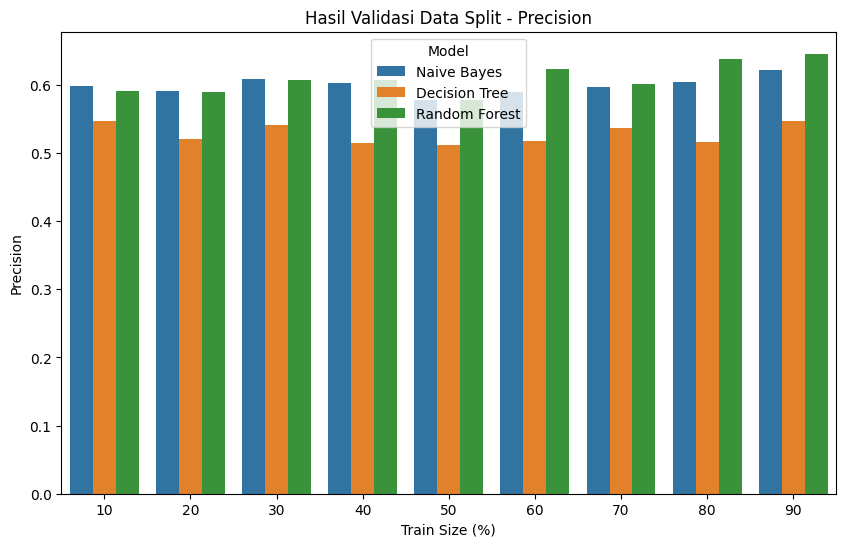

<ipython-input-10-c1ac0a6e0f04>:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Train Size (%)', y='Recall', hue='Model', data=df, ci=None)


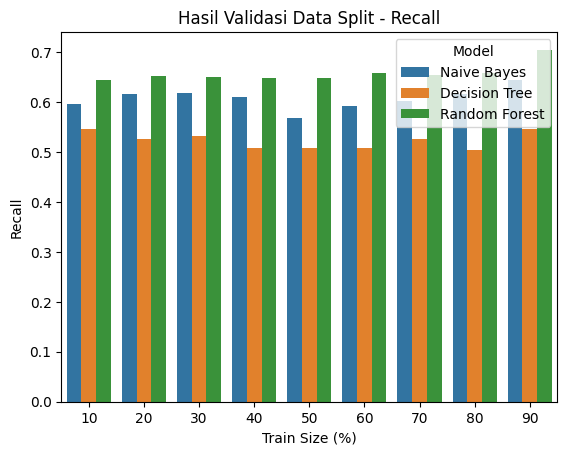

<ipython-input-10-c1ac0a6e0f04>:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Train Size (%)', y='F1 Score', hue='Model', data=df, ci=None)


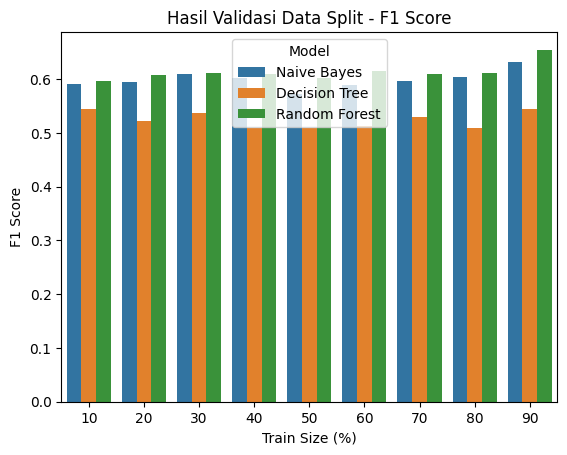

<ipython-input-10-c1ac0a6e0f04>:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Model', y='Precision', data=df, ci=None)


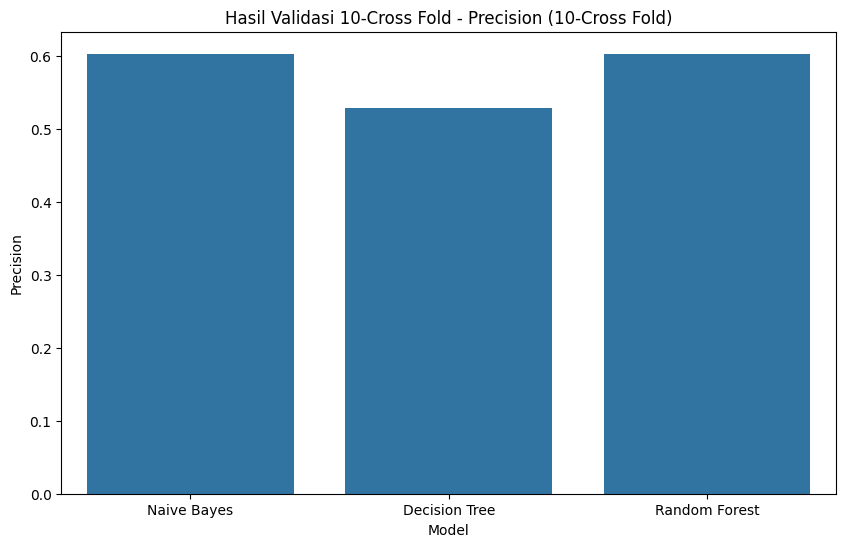

<ipython-input-10-c1ac0a6e0f04>:40: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Model', y='Recall', data=df, ci=None)


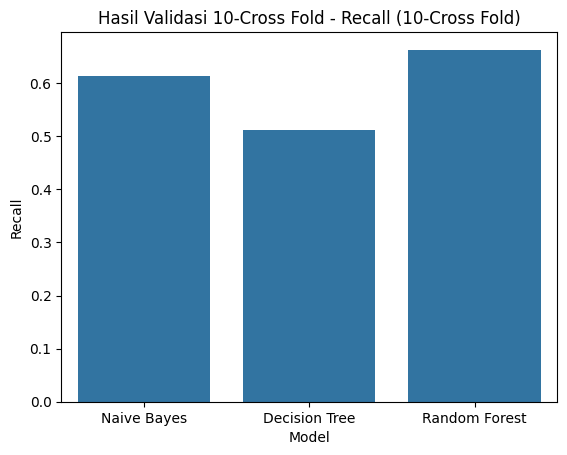

<ipython-input-10-c1ac0a6e0f04>:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Model', y='F1 Score', data=df, ci=None)


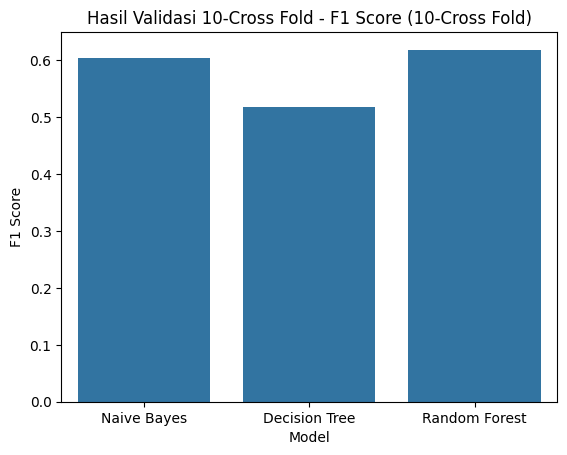

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menampilkan hasil evaluasi Data Split dalam bentuk grafik bar
def plot_evaluation_results(df, title):
    # Set ukuran grafik
    plt.figure(figsize=(10, 6))

    # Membuat grafik bar
    sns.barplot(x='Train Size (%)', y='Precision', hue='Model', data=df, ci=None)
    plt.title(f'{title} - Precision')
    plt.xlabel('Train Size (%)')
    plt.ylabel('Precision')
    plt.show()

    sns.barplot(x='Train Size (%)', y='Recall', hue='Model', data=df, ci=None)
    plt.title(f'{title} - Recall')
    plt.xlabel('Train Size (%)')
    plt.ylabel('Recall')
    plt.show()

    sns.barplot(x='Train Size (%)', y='F1 Score', hue='Model', data=df, ci=None)
    plt.title(f'{title} - F1 Score')
    plt.xlabel('Train Size (%)')
    plt.ylabel('F1 Score')
    plt.show()

# Menampilkan hasil evaluasi 10-Cross Fold dalam bentuk grafik bar
def plot_kfold_results(df, title):
    # Set ukuran grafik
    plt.figure(figsize=(10, 6))

    # Membuat grafik bar
    sns.barplot(x='Model', y='Precision', data=df, ci=None)
    plt.title(f'{title} - Precision (10-Cross Fold)')
    plt.xlabel('Model')
    plt.ylabel('Precision')
    plt.show()

    sns.barplot(x='Model', y='Recall', data=df, ci=None)
    plt.title(f'{title} - Recall (10-Cross Fold)')
    plt.xlabel('Model')
    plt.ylabel('Recall')
    plt.show()

    sns.barplot(x='Model', y='F1 Score', data=df, ci=None)
    plt.title(f'{title} - F1 Score (10-Cross Fold)')
    plt.xlabel('Model')
    plt.ylabel('F1 Score')
    plt.show()

# Menampilkan grafik hasil evaluasi Data Split
plot_evaluation_results(df_split, 'Hasil Validasi Data Split')

# Menampilkan grafik hasil evaluasi 10-Cross Fold
plot_kfold_results(df_kfold, 'Hasil Validasi 10-Cross Fold')
